8. In the lab, a classification tree was applied to the Carseats data set af-
ter converting Sales into a qualitative response variable. Now we will
seek to predict Sales using regression trees and related approaches,
treating the response as a quantitative variable.

(a) Split the data set into a training set and a test set.

In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split

carseats = pd.read_csv("Carseats.csv")

y = carseats["Sales"]

X = carseats.drop(columns=["Sales"])
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=1
)

print(X_train.shape, X_test.shape)


(200, 11) (200, 11)


(b) Fit a regression tree to the training set. Plot the tree, and inter-
pret the results. What test MSE do you obtain?

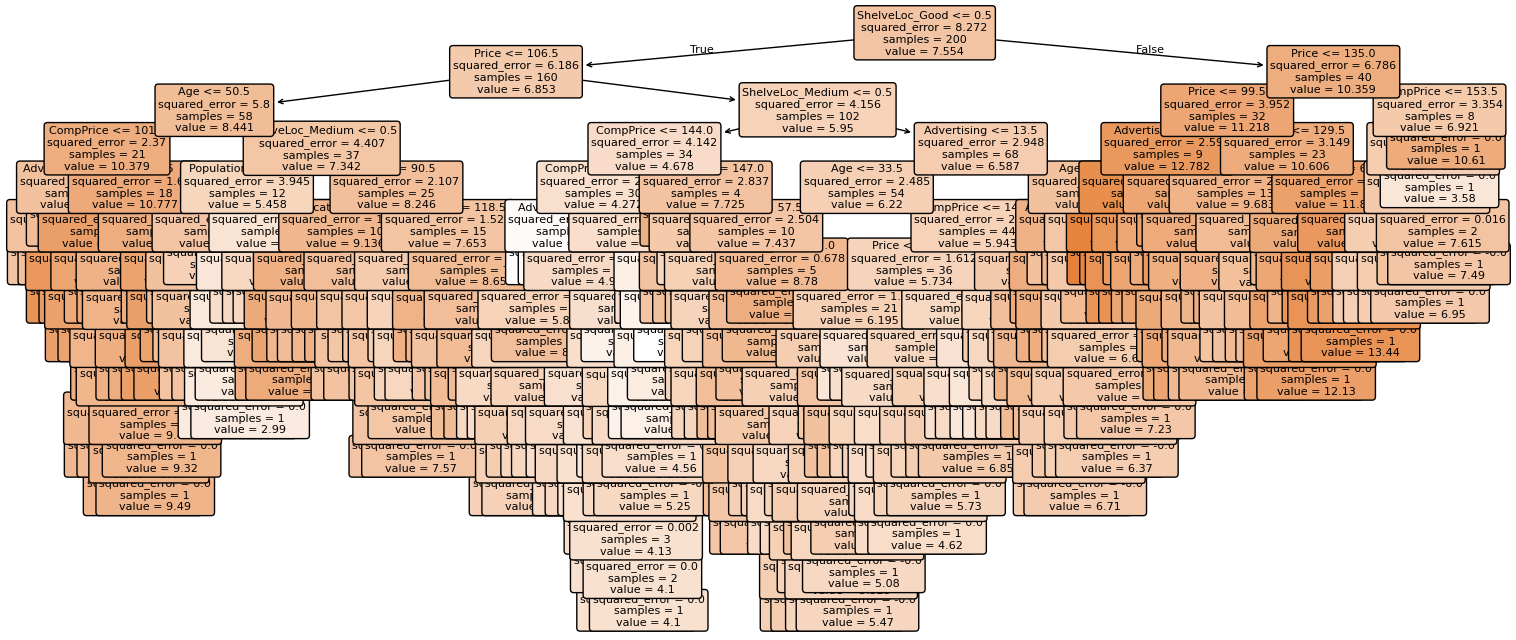

In [46]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error

tree_reg = DecisionTreeRegressor(random_state=1)
tree_reg.fit(X_train, y_train)

plt.figure(figsize=(18, 8))
plot_tree(
    tree_reg,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()


In [47]:
y_pred_test = tree_reg.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred_test)
print("Test MSE (unpruned regression tree):", test_mse)


Test MSE (unpruned regression tree): 6.4677834999999995


(c) Use cross-validation in order to determine the optimal level of
tree complexity. Does pruning the tree improve the test MSE?

In [48]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, KFold

path = DecisionTreeRegressor(random_state=1).cost_complexity_pruning_path(
    X_train, y_train
)
ccp_alphas = path.ccp_alphas

ccp_alphas = ccp_alphas[:-1]

cv_mse = []
kf = KFold(n_splits=10, shuffle=True, random_state=1)

for alpha in ccp_alphas:
    tree_pruned = DecisionTreeRegressor(random_state=1, ccp_alpha=alpha)
    scores = cross_val_score(
        tree_pruned,
        X_train,
        y_train,
        scoring="neg_mean_squared_error",
        cv=kf
    )
    cv_mse.append(-scores.mean())

cv_mse = np.array(cv_mse)

best_alpha = ccp_alphas[np.argmin(cv_mse)]
print("Best ccp_alpha from CV:", best_alpha)


Best ccp_alpha from CV: 0.31523238851350155


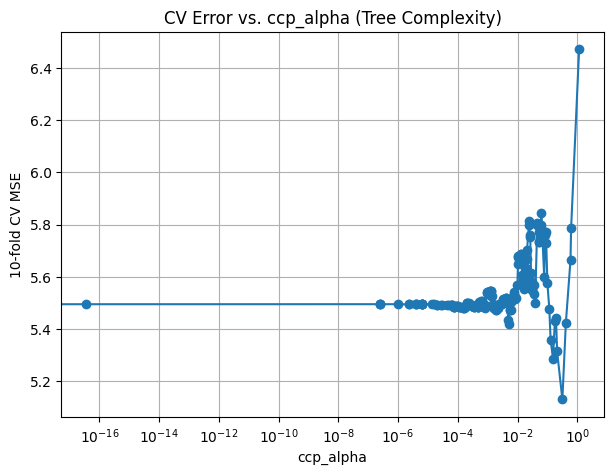

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(ccp_alphas, cv_mse, marker="o")
plt.xlabel("ccp_alpha")
plt.ylabel("10-fold CV MSE")
plt.title("CV Error vs. ccp_alpha (Tree Complexity)")
plt.xscale("log")
plt.grid(True)
plt.show()


In [50]:
tree_best = DecisionTreeRegressor(random_state=1, ccp_alpha=best_alpha)
tree_best.fit(X_train, y_train)

y_pred_test_pruned = tree_best.predict(X_test)

from sklearn.metrics import mean_squared_error
test_mse_pruned = mean_squared_error(y_test, y_pred_test_pruned)
print("Test MSE (pruned regression tree):", test_mse_pruned)


Test MSE (pruned regression tree): 5.105824732518415


(d) Use the bagging approach in order to analyze this data. What
test MSE do you obtain? Use the feature_importance_ values to
determine which variables are most important.

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

p = X_train.shape[1]


bagging_model = RandomForestRegressor(
    n_estimators=500,
    max_features=p,
    bootstrap=True,
    random_state=1,
    n_jobs=-1
)

bagging_model.fit(X_train, y_train)

y_pred_bag = bagging_model.predict(X_test)
bag_test_mse = mean_squared_error(y_test, y_pred_bag)
print("Test MSE (bagging):", bag_test_mse)

importances = bagging_model.feature_importances_
feature_names = np.array(X_train.columns)

idx = np.argsort(importances)[::-1]

print("\nTop 10 important features (bagging):")
for i in range(10):
    print(f"{i+1}. {feature_names[idx[i]]}: {importances[idx[i]]:.3f}")


Test MSE (bagging): 2.8348328775340077

Top 10 important features (bagging):
1. Price: 0.298
2. ShelveLoc_Good: 0.231
3. Age: 0.107
4. CompPrice: 0.084
5. ShelveLoc_Medium: 0.084
6. Advertising: 0.058
7. Income: 0.053
8. Population: 0.046
9. Education: 0.028
10. Urban_Yes: 0.007


(e) Use random forests to analyze this data. What test MSE do
you obtain? Use the feature_importance_ values to determine
which variables are most important. Describe the effect of m, the
number of variables considered at each split, on the error rate
obtained.

In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

p = X_train.shape[1]

m_values = [1, 2, 3, 4, 5, 6, 7, 8, 9,  10, int(np.sqrt(p)), p//3, p]
m_values = sorted(set([m for m in m_values if 1 <= m <= p]))

test_mse_rf = []

for m in m_values:
    rf = RandomForestRegressor(
        n_estimators=500,
        max_features=m,
        bootstrap=True,
        random_state=1,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    test_mse_rf.append(mse)
    print(f"m = {m:2d}, Test MSE (RF) = {mse:.4f}")

best_idx = int(np.argmin(test_mse_rf))
best_m = m_values[best_idx]
best_mse = test_mse_rf[best_idx]
print("\nBest m:", best_m, "with Test MSE:", best_mse)


m =  1, Test MSE (RF) = 4.0312
m =  2, Test MSE (RF) = 3.3411
m =  3, Test MSE (RF) = 2.9505
m =  4, Test MSE (RF) = 2.8041
m =  5, Test MSE (RF) = 2.7957
m =  6, Test MSE (RF) = 2.7081
m =  7, Test MSE (RF) = 2.7517
m =  8, Test MSE (RF) = 2.7901
m =  9, Test MSE (RF) = 2.7545
m = 10, Test MSE (RF) = 2.8307
m = 11, Test MSE (RF) = 2.8348

Best m: 6 with Test MSE: 2.7081217893340046


In [53]:
rf_best = RandomForestRegressor(
    n_estimators=500,
    max_features=best_m,
    bootstrap=True,
    random_state=1,
    n_jobs=-1
)
rf_best.fit(X_train, y_train)

importances = rf_best.feature_importances_
feature_names = np.array(X_train.columns)
idx = np.argsort(importances)[::-1]

print("\nTop 10 important features (random forest):")
for i in range(10):
    print(f"{i+1}. {feature_names[idx[i]]}: {importances[idx[i]]:.3f}")



Top 10 important features (random forest):
1. Price: 0.277
2. ShelveLoc_Good: 0.206
3. Age: 0.108
4. CompPrice: 0.092
5. Advertising: 0.075
6. ShelveLoc_Medium: 0.067
7. Income: 0.066
8. Population: 0.055
9. Education: 0.037
10. Urban_Yes: 0.009


(f) Now analyze the data using BART, and report your results.

In [57]:
import pymc as pm
import pymc_bart as pmb
from sklearn.metrics import mean_squared_error

print("Starting BART analysis...")

# Convert pandas DataFrames/Series to NumPy arrays and cast to float
X_train_np = X_train.values.astype(float)
y_train_np = y_train.values.astype(float)
X_test_np = X_test.values.astype(float)
y_test_np = y_test.values.astype(float)

with pm.Model() as bart_model:
    # Define Data for X and Y to allow for easy switching between train and test
    X_shared = pm.Data("X", X_train_np)
    Y_shared = pm.Data("Y", y_train_np)

    # Initialize the BART model as the mean function
    # m: number of trees
    # alpha, beta: parameters for prior over terminal node splitting
    mu = pmb.BART("mu", X=X_shared, Y=Y_shared, m=50, alpha=0.95, beta=2)

    # Add a likelihood for the observed data
    sigma = pm.HalfNormal("sigma", sigma=1) # Standard deviation of the noise
    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=Y_shared)

    # Sample from the posterior distribution
    # draws: number of samples from the posterior
    # tune: number of tuning (warmup) samples
    # chains: number of independent MCMC chains
    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        random_seed=1,
        target_accept=0.9,
        return_inferencedata=True,
        compute_convergence_checks=False # Disable convergence checks for faster execution if needed
    )

    print("BART sampling complete.")

    # Make predictions on the test set
    # Switch X_shared to X_test_np for out-of-sample prediction
    pm.set_data({"X": X_test_np}, model=bart_model)

    # Generate posterior predictive samples using PyMC's generic predictive sampler
    ppc = pm.sample_posterior_predictive(
        idata,
        model=bart_model,
        var_names=["likelihood"], # Predict the observed likelihood variable
        random_seed=1
    )

    # Extract predictions for 'likelihood' and calculate the mean
    y_pred_bart = ppc.posterior_predictive["likelihood"].mean(("chain", "draw")).values

    # Calculate Test MSE
    test_mse_bart = mean_squared_error(y_test_np, y_pred_bart)
    print(f"\nTest MSE (BART): {test_mse_bart:.4f}")

Starting BART analysis...


Output()

BART sampling complete.


Output()


Test MSE (BART): 2.1266
